# **MNIST Multilabel Classification**

## **Importing Dependencies**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

import joblib

In [2]:
from sklearn.model_selection import cross_val_predict
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.metrics import ConfusionMatrixDisplay, multilabel_confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import average_precision_score, roc_auc_score

In [3]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## **Data Collection & Exploration**

In [4]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [5]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [6]:
mnist.details

{'id': '554',
 'name': 'mnist_784',
 'version': '1',
 'description_version': '2',
 'format': 'ARFF',
 'creator': ['Yann LeCun', 'Corinna Cortes', 'Christopher J.C. Burges'],
 'upload_date': '2014-09-29T03:28:38',
 'language': 'English',
 'licence': 'Public',
 'url': 'https://openml.org/data/v1/download/52667/mnist_784.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0554/dataset_554.pq',
 'file_id': '52667',
 'default_target_attribute': 'class',
 'tag': ['Artificial Intelligence',
  'AzurePilot',
  'Computer Vision',
  'Data Sets',
  'Kaggle',
  'Machine Learning',
  'OpenML-CC18',
  'OpenML100',
  'study_1',
  'study_123',
  'study_41',
  'study_99',
  'vision'],
 'visibility': 'public',
 'status': 'active',
 'processing_date': '2020-11-20 20:12:09',
 'md5_checksum': '0298d579eb1b86163de7723944c7e495'}

In [7]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [8]:
mnist.categories

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}

In [9]:
X = mnist.data
Y = mnist.target

In [10]:
X.shape

(70000, 784)

In [11]:
Y.shape

(70000,)

In [12]:
def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

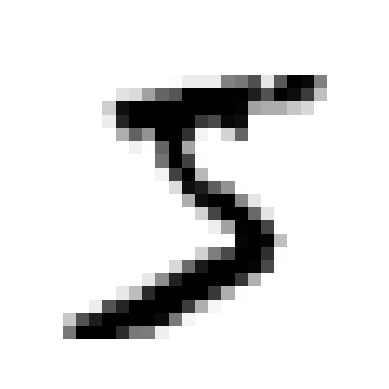

In [13]:
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [14]:
Y[0]

'5'

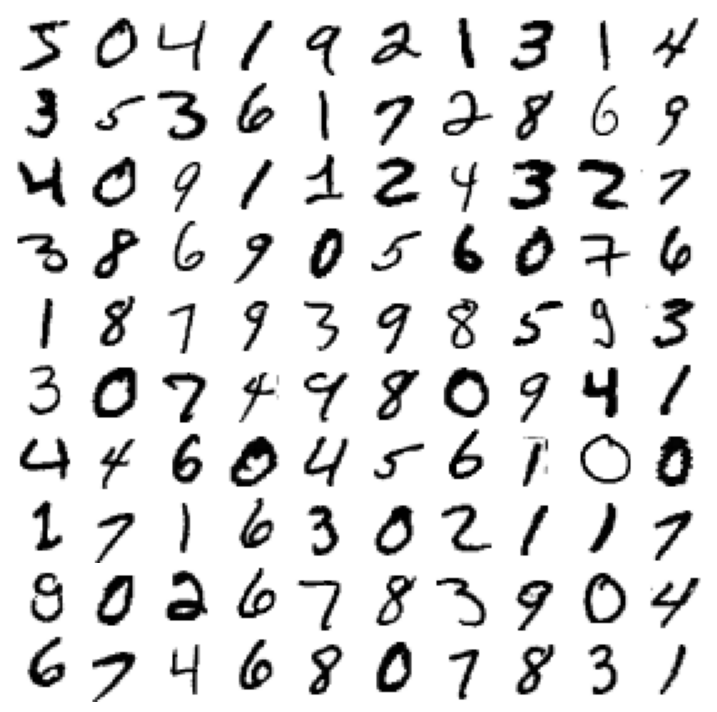

In [15]:
plt.figure(figsize=(9,9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx+1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

## **Data Spliting**

In [16]:
X_train, X_test, Y_train, Y_test = X[:60000], X[60000:], Y[:60000], Y[60000:]

## **Multi-Label Setup**  

In [17]:
Y_train_large = (Y_train >= '5').astype(int)

Y_train_odd = (Y_train.astype(int) % 2 != 0).astype(int)

prime_digits = {'2', '3', '5', '7'}
Y_train_prime = np.isin(Y_train, list(prime_digits)).astype(int)

Y_train_multilabel = np.c_[Y_train_large, Y_train_odd, Y_train_prime]

In [18]:
Y_test_large = (Y_test >= '5').astype(int)

Y_test_odd = (Y_test.astype(int) % 2 != 0).astype(int)

prime_digits = {'2', '3', '5', '7'}
Y_test_prime = np.isin(Y_test, list(prime_digits)).astype(int)

Y_test_multilabel = np.c_[Y_test_large, Y_test_odd, Y_test_prime]

In [19]:
target_labels = ['Is_Large', 'Is_Odd', 'Is_Prime']

## **Model Training & Evaluation**

In [20]:
def evaluate_multilabel_pr_roc_performance(
    Y_true_multilabel: np.ndarray,
    Y_scores: np.ndarray,
    label_names: list[str] | np.ndarray) -> tuple[pd.DataFrame, float, float]:

    """
    Computes and prints detailed Per-Class and Global Macro Performance Metrics (ROC-AUC Score and Average Precision Score) for a
    Multilabel Classification Model.

    Parameters:
    -----------
    Y_true_multilabel : ndarray of shape (n_samples, n_labels)
                 - Binarized Ground Truth Labels.
    Y_scores : ndarray of shape (n_samples, n_labels)
               - Target Scores / Decision Function Values from the Model.
    label_names : list or array of shape (n_labels,)
              - Names of Target Labels.

    Returns:
    --------
    metrics_df : pd.DataFrame
                 - DataFrame containing Per-Label Metrics.
    macro_auc : float
                - Global Macro ROC-AUC Score.
    macro_ap : float
               - Global Macro Average Precision Score.
    """

    performance_metrics = []

    for i in range(len(label_names)):
        y_true_label = Y_true_multilabel[:, i]
        y_score_label = Y_scores[:, i]

        auc_score = roc_auc_score(y_true_label, y_score_label)
        ap_score = average_precision_score(y_true_label, y_score_label)

        performance_metrics.append({
            "Label": label_names[i],
            "ROC-AUC Score": auc_score,
            "AP Score": ap_score
        })

    metrics_df = pd.DataFrame(performance_metrics)
    
    print(metrics_df.to_string(index=False, formatters={
        "ROC-AUC Score": "{:.4f}".format, 
        "AP Score": "{:.4f}".format
    }))

    macro_auc = roc_auc_score(Y_true_multilabel, Y_scores, average="macro")
    macro_ap = average_precision_score(Y_true_multilabel, Y_scores, average="macro")

    print("\n")
    print(f"Macro ROC-AUC Score: {macro_auc:.5f}")
    print(f"Macro Average Precision Score: {macro_ap:.5f}")

    return metrics_df, macro_auc, macro_ap

### **Support Vector Machine (SVM) - RBF Kernel - MultiOutput Strategy**

In [21]:
independent_svm_clf = MultiOutputClassifier(SVC(kernel='rbf', random_state=3), n_jobs=-1)

In [22]:
independent_svm_clf.fit(X_train, Y_train_multilabel)

MultiOutputClassifier(estimator=SVC(random_state=3), n_jobs=-1)

In [23]:
independent_svm_clf.estimators_

[SVC(random_state=3), SVC(random_state=3), SVC(random_state=3)]

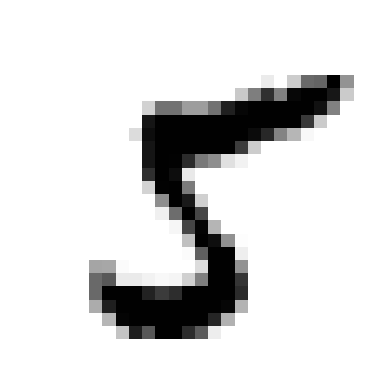

In [24]:
some_digit = X_train[236]
plot_digit(some_digit)
plt.show()

In [25]:
binary_predictions = independent_svm_clf.predict([some_digit])
print(f"Predicted Binary Matrix: {binary_predictions}")

Predicted Binary Matrix: [[1 1 1]]


In [26]:
some_digit_scores = np.array([
    estimator.decision_function([some_digit])[0] for estimator in independent_svm_clf.estimators_
])
print(f"Decision Function Scores: {some_digit_scores.round(3)}")

Decision Function Scores: [2.476 1.859 2.744]


In [27]:
predicted_traits = [target_labels[i] for i, distance in enumerate(some_digit_scores) if distance > 0]
predicted_traits

['Is_Large', 'Is_Odd', 'Is_Prime']

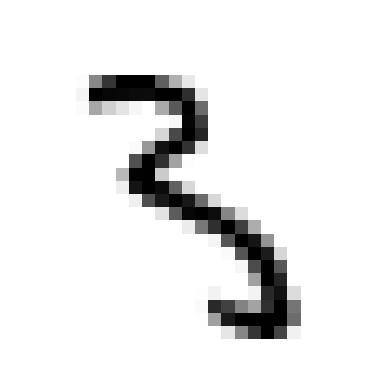

In [28]:
some_digit = X_train[228]
plot_digit(some_digit)
plt.show()

In [29]:
binary_predictions = independent_svm_clf.predict([some_digit])
print(f"Predicted Binary Matrix: {binary_predictions}")

Predicted Binary Matrix: [[0 1 1]]


In [30]:
some_digit_scores = np.array([
    estimator.decision_function([some_digit])[0] for estimator in independent_svm_clf.estimators_
])
print(f"Decision Function Scores: {some_digit_scores.round(3)}")

Decision Function Scores: [-0.832  1.     0.831]


In [31]:
predicted_traits = [target_labels[i] for i, distance in enumerate(some_digit_scores) if distance > 0]
predicted_traits

['Is_Odd', 'Is_Prime']

In [32]:
Y_scores_independent_svm_list = [
    cross_val_predict(estimator, X_train, Y_train_multilabel[:,i], cv=3, method="decision_function",  n_jobs=-1)
    for i, estimator in enumerate(independent_svm_clf.estimators_)
]

Y_scores_independent_svm = np.column_stack(Y_scores_independent_svm_list)

In [33]:
metrics_df, macro_auc, macro_ap = evaluate_multilabel_pr_roc_performance(Y_train_multilabel, Y_scores_independent_svm, target_labels)

   Label ROC-AUC Score AP Score
Is_Large        0.9971   0.9966
  Is_Odd        0.9982   0.9983
Is_Prime        0.9975   0.9962


Macro ROC-AUC Score: 0.99759
Macro Average Precision Score: 0.99703


In [34]:
Y_train_pred_independent_svm = (Y_scores_independent_svm > 0).astype(int)

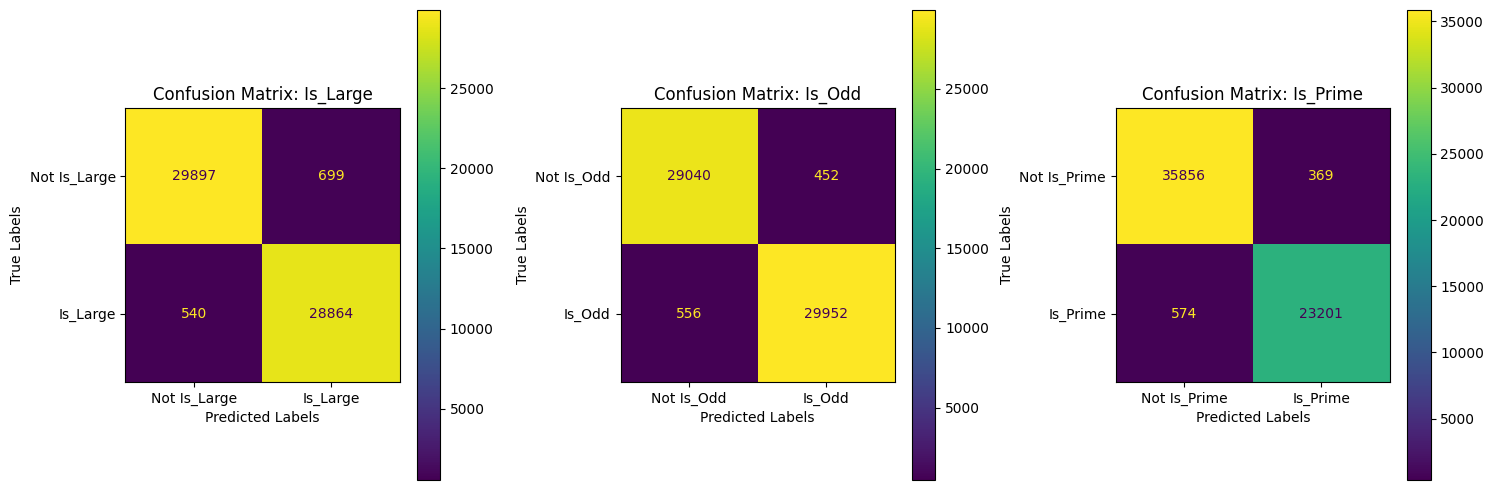

In [35]:
confusion_matrix = multilabel_confusion_matrix(Y_train_multilabel, Y_train_pred_independent_svm)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for idx, matrix in enumerate(confusion_matrix):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=[f"Not {target_labels[idx]}", target_labels[idx]])
    
    disp.plot(ax=axes[idx], values_format='d')
    
    axes[idx].set_title(f"Confusion Matrix: {target_labels[idx]}")
    axes[idx].set_xlabel("Predicted Labels")
    axes[idx].set_ylabel("True Labels")
    
plt.tight_layout()
plt.show()

In [36]:
print("Subset Accuracy =", accuracy_score(Y_train_multilabel, Y_train_pred_independent_svm))
print("Precision =", precision_score(Y_train_multilabel, Y_train_pred_independent_svm, average="weighted"))
print("Recall =", recall_score(Y_train_multilabel, Y_train_pred_independent_svm, average="weighted"))
print("F1 Score =", f1_score(Y_train_multilabel, Y_train_pred_independent_svm, average="weighted"))

Subset Accuracy = 0.9589
Precision = 0.9818251816191594
Recall = 0.9800446903342216
F1 Score = 0.9809261696267948


In [37]:
print(classification_report(Y_train_multilabel, Y_train_pred_independent_svm, target_names=target_labels, zero_division=0))

              precision    recall  f1-score   support

    Is_Large       0.98      0.98      0.98     29404
      Is_Odd       0.99      0.98      0.98     30508
    Is_Prime       0.98      0.98      0.98     23775

   micro avg       0.98      0.98      0.98     83687
   macro avg       0.98      0.98      0.98     83687
weighted avg       0.98      0.98      0.98     83687
 samples avg       0.79      0.79      0.79     83687



### **Support Vector Machine (SVM) - RBF Kernel - Classifier Chain Strategy**

In [38]:
dependent_svm_clf = ClassifierChain(SVC(kernel='rbf', random_state=3))

In [39]:
dependent_svm_clf.fit(X_train, Y_train_multilabel)

ClassifierChain(base_estimator=SVC(random_state=3))

In [40]:
dependent_svm_clf.estimators_

[SVC(random_state=3), SVC(random_state=3), SVC(random_state=3)]

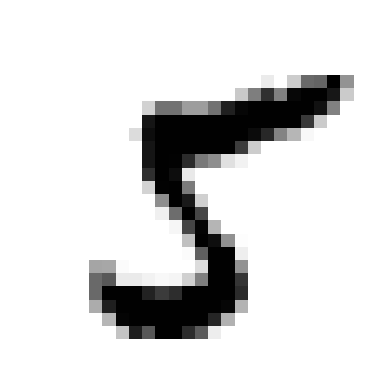

In [41]:
some_digit = X_train[236]
plot_digit(some_digit)
plt.show()

In [42]:
binary_chain_predictions = dependent_svm_clf.predict([some_digit])
print(f"Predicted Binary Matrix: {binary_chain_predictions}")

Predicted Binary Matrix: [[1. 1. 1.]]


In [43]:
chain_matrix_scores = dependent_svm_clf.decision_function([some_digit])

In [44]:
some_digit_chain_scores = chain_matrix_scores[0]
some_digit_chain_scores.round(3)

array([2.476, 1.859, 2.744])

In [45]:
predicted_chain_traits = [target_labels[i] for i, distance in enumerate(some_digit_chain_scores) if distance > 0]
predicted_chain_traits

['Is_Large', 'Is_Odd', 'Is_Prime']

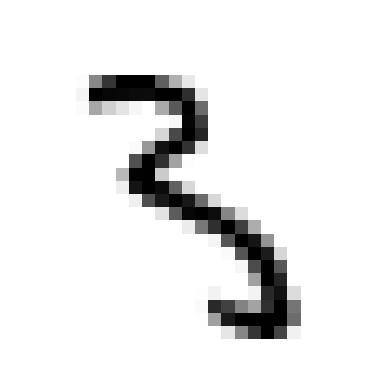

In [46]:
some_digit = X_train[228]
plot_digit(some_digit)
plt.show()

In [47]:
binary_chain_predictions = dependent_svm_clf.predict([some_digit])
print(f"Predicted Binary Matrix: {binary_chain_predictions}")

Predicted Binary Matrix: [[0. 1. 1.]]


In [48]:
chain_matrix_scores = dependent_svm_clf.decision_function([some_digit])

In [49]:
some_digit_chain_scores = chain_matrix_scores[0]
some_digit_chain_scores.round(3)

array([-0.832,  1.   ,  0.831])

In [50]:
predicted_chain_traits = [target_labels[i] for i, distance in enumerate(some_digit_chain_scores) if distance > 0]
predicted_chain_traits

['Is_Odd', 'Is_Prime']

In [51]:
Y_scores_dependent_svm = cross_val_predict(dependent_svm_clf, X_train, Y_train_multilabel, method="decision_function", cv=3, n_jobs=-1)

In [52]:
metrics_df, macro_auc, macro_ap = evaluate_multilabel_pr_roc_performance(Y_train_multilabel, Y_scores_dependent_svm, target_labels)

   Label ROC-AUC Score AP Score
Is_Large        0.9971   0.9966
  Is_Odd        0.9982   0.9983
Is_Prime        0.9975   0.9962


Macro ROC-AUC Score: 0.99759
Macro Average Precision Score: 0.99703


In [53]:
Y_train_pred_dependent_svm = (Y_scores_dependent_svm > 0).astype(int)

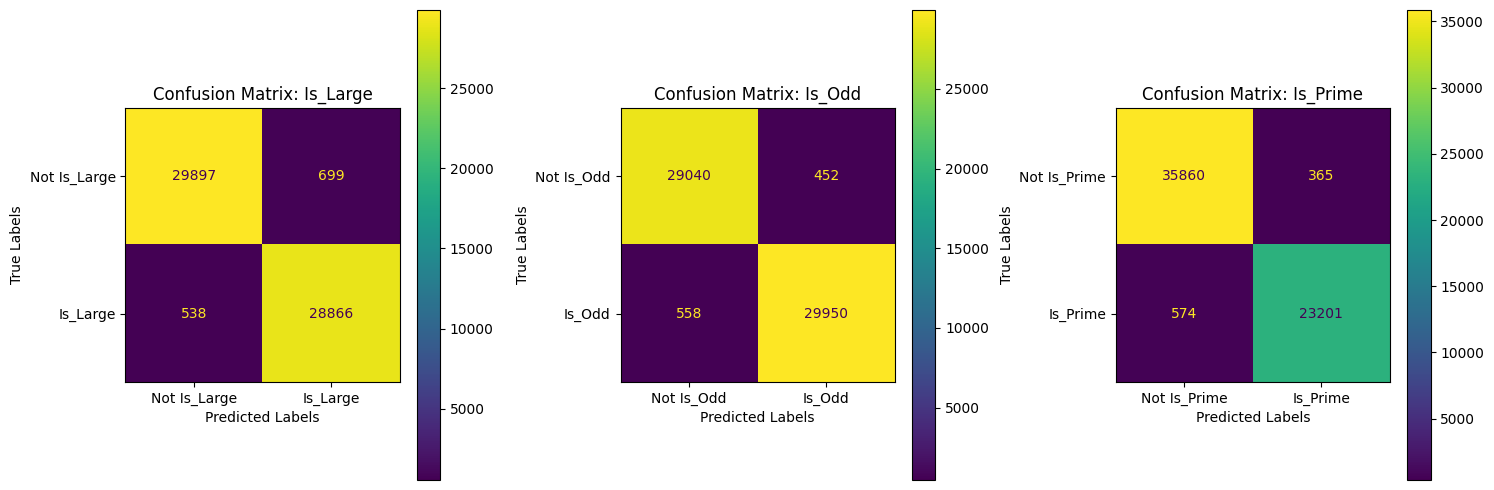

In [54]:
confusion_matrix = multilabel_confusion_matrix(Y_train_multilabel, Y_train_pred_dependent_svm)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for idx, matrix in enumerate(confusion_matrix):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=[f"Not {target_labels[idx]}", target_labels[idx]])
    
    disp.plot(ax=axes[idx], values_format='d')
    
    axes[idx].set_title(f"Confusion Matrix: {target_labels[idx]}")
    axes[idx].set_xlabel("Predicted Labels")
    axes[idx].set_ylabel("True Labels")
    
plt.tight_layout()
plt.show()

In [55]:
print("Subset Accuracy =", accuracy_score(Y_train_multilabel, Y_train_pred_dependent_svm))
print("Precision =", precision_score(Y_train_multilabel, Y_train_pred_dependent_svm, average="weighted"))
print("Recall =", recall_score(Y_train_multilabel, Y_train_pred_dependent_svm, average="weighted"))
print("F1 Score =", f1_score(Y_train_multilabel, Y_train_pred_dependent_svm, average="weighted"))

Subset Accuracy = 0.95895
Precision = 0.9818728532074548
Recall = 0.9800446903342216
F1 Score = 0.9809496944877927


In [56]:
print(classification_report(Y_train_multilabel, Y_train_pred_dependent_svm, target_names=target_labels, zero_division=0))

              precision    recall  f1-score   support

    Is_Large       0.98      0.98      0.98     29404
      Is_Odd       0.99      0.98      0.98     30508
    Is_Prime       0.98      0.98      0.98     23775

   micro avg       0.98      0.98      0.98     83687
   macro avg       0.98      0.98      0.98     83687
weighted avg       0.98      0.98      0.98     83687
 samples avg       0.79      0.79      0.79     83687



### **Random Forest**

In [57]:
forest_clf = RandomForestClassifier(n_jobs=-1, random_state=3)

In [58]:
forest_clf.fit(X_train, Y_train_multilabel)

RandomForestClassifier(n_jobs=-1, random_state=3)

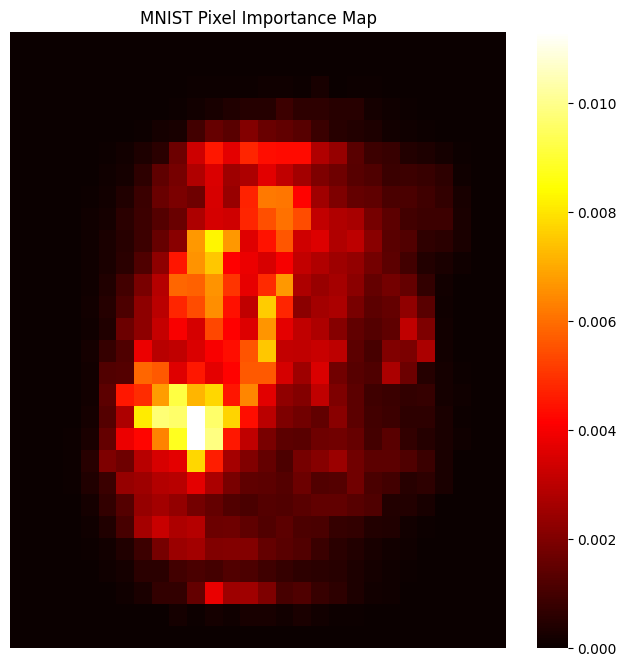

In [59]:
importances = forest_clf.feature_importances_
importance_matrix = importances.reshape(28,28)

plt.figure(figsize=(8,8))
sns.heatmap(importance_matrix, cmap='hot', cbar=True, xticklabels=False, yticklabels=False)
plt.title("MNIST Pixel Importance Map")
plt.show()

In [60]:
Y_probas_forest = cross_val_predict(forest_clf, X_train, Y_train_multilabel, cv=3, method="predict_proba", n_jobs=-1)

In [61]:
Y_scores_forest = np.column_stack([prob[:, 1] for prob in Y_probas_forest])

In [62]:
metrics_df, macro_auc, macro_ap = evaluate_multilabel_pr_roc_performance(Y_train_multilabel, Y_scores_forest, target_labels)

   Label ROC-AUC Score AP Score
Is_Large        0.9971   0.9967
  Is_Odd        0.9976   0.9976
Is_Prime        0.9980   0.9969


Macro ROC-AUC Score: 0.99755
Macro Average Precision Score: 0.99707


In [63]:
Y_train_pred_forest = (Y_scores_forest >= 0.5).astype(int)

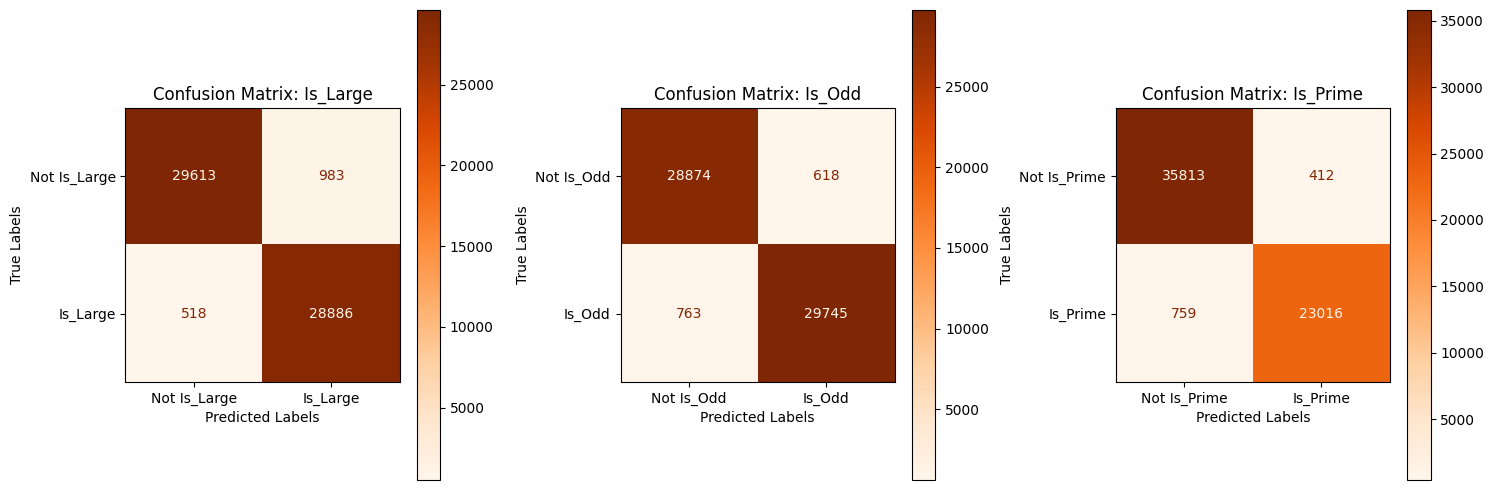

In [64]:
confusion_matrix = multilabel_confusion_matrix(Y_train_multilabel, Y_train_pred_forest)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for idx, matrix in enumerate(confusion_matrix):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=[f"Not {target_labels[idx]}", target_labels[idx]])
    
    disp.plot(cmap='Oranges', ax=axes[idx], values_format='d')
    
    axes[idx].set_title(f"Confusion Matrix: {target_labels[idx]}")
    axes[idx].set_xlabel("Predicted Labels")
    axes[idx].set_ylabel("True Labels")
    
plt.tight_layout()
plt.show()

In [65]:
print("Accuracy =", accuracy_score(Y_train_multilabel, Y_train_pred_forest))
print("Precision =", precision_score(Y_train_multilabel, Y_train_pred_forest, average="weighted"))
print("Recall =", recall_score(Y_train_multilabel, Y_train_pred_forest, average="weighted"))
print("F1 Score =", f1_score(Y_train_multilabel, Y_train_pred_forest, average="weighted"))

Accuracy = 0.9504
Precision = 0.9760207650451287
Recall = 0.9756234540609653
F1 Score = 0.9757840374227472


In [66]:
print(classification_report(Y_train_multilabel, Y_train_pred_forest, target_names=target_labels, zero_division=0))

              precision    recall  f1-score   support

    Is_Large       0.97      0.98      0.97     29404
      Is_Odd       0.98      0.97      0.98     30508
    Is_Prime       0.98      0.97      0.98     23775

   micro avg       0.98      0.98      0.98     83687
   macro avg       0.98      0.98      0.98     83687
weighted avg       0.98      0.98      0.98     83687
 samples avg       0.79      0.79      0.78     83687



## **Final Model Selection & Evaluation** 

In [67]:
final_model = dependent_svm_clf

In [68]:
final_model.fit(X_train, Y_train_multilabel)

ClassifierChain(base_estimator=SVC(random_state=3))

In [69]:
hasattr(final_model, 'predict_proba')

False

In [70]:
hasattr(final_model, 'decision_function')

True

In [71]:
Y_test_scores = final_model.decision_function(X_test)

In [72]:
Y_test_pred = (Y_test_scores > 0).astype(int)

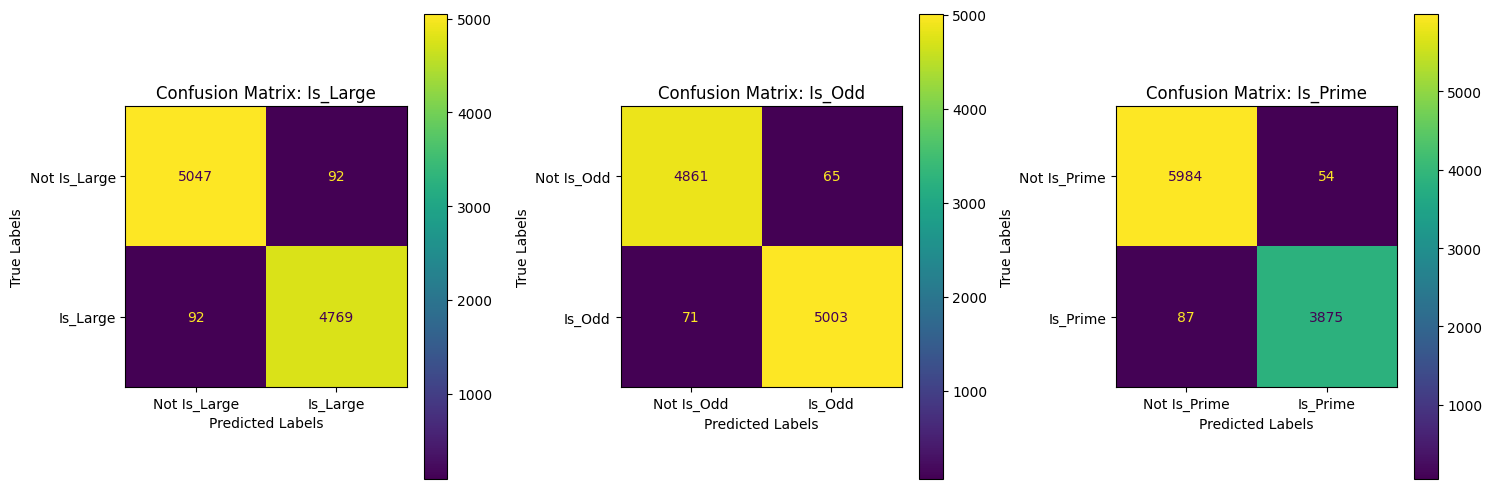

In [73]:
confusion_matrix = multilabel_confusion_matrix(Y_test_multilabel, Y_test_pred)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for idx, matrix in enumerate(confusion_matrix):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=[f"Not {target_labels[idx]}", target_labels[idx]])
    
    disp.plot(ax=axes[idx], values_format='d')
    
    axes[idx].set_title(f"Confusion Matrix: {target_labels[idx]}")
    axes[idx].set_xlabel("Predicted Labels")
    axes[idx].set_ylabel("True Labels")
    
plt.tight_layout()
plt.show()

In [74]:
print("Accuracy =", accuracy_score(Y_test_multilabel, Y_test_pred))
print("Precision =", precision_score(Y_test_multilabel, Y_test_pred, average="weighted"))
print("Recall =", recall_score(Y_test_multilabel, Y_test_pred, average="weighted"))
print("F1 Score =", f1_score(Y_test_multilabel, Y_test_pred, average="weighted"))

Accuracy = 0.9648
Precision = 0.9847786929585474
Recall = 0.9820105058645751
F1 Score = 0.9833895762895316


In [75]:
print(classification_report(Y_test_multilabel, Y_test_pred, target_names=target_labels, zero_division=0))

              precision    recall  f1-score   support

    Is_Large       0.98      0.98      0.98      4861
      Is_Odd       0.99      0.99      0.99      5074
    Is_Prime       0.99      0.98      0.98      3962

   micro avg       0.98      0.98      0.98     13897
   macro avg       0.98      0.98      0.98     13897
weighted avg       0.98      0.98      0.98     13897
 samples avg       0.79      0.79      0.79     13897



In [76]:
metrics_df, macro_auc, macro_ap = evaluate_multilabel_pr_roc_performance(Y_test_multilabel, Y_test_scores, target_labels)

   Label ROC-AUC Score AP Score
Is_Large        0.9977   0.9976
  Is_Odd        0.9989   0.9989
Is_Prime        0.9989   0.9982


Macro ROC-AUC Score: 0.99850
Macro Average Precision Score: 0.99822


In [77]:
joblib.dump(final_model, "mnist_multilabel_chain_svm_rbf.pkl", compress=3)
print("Success!!")

Success!!
